## Region Proposal

1. Region proposal is a technique that helps identify islands of regions where the pixels are similar to one another.

2. Generating  a region proposal comes in handy for object detection where we must identify the locations of objects present in an image.


### Selective Search

1. Selective Search is a region proposal algorithm used for object localization, where it generates proposals of regions that are likely to be grounded together based on their pixel intensities.

2. Selective Search groups pixel based on the hierarchical grouping of similar pixels , which in turn leverages the color, texture, size and shape compatibility of content within an image.

3. Initially Selective Search oversegments an image by grouping pixels based on the preceding attributes.

4. Then, It iterates through these over-segmented groups and groups them based on similarity.

5. At each iteration, it combines smaller regions to form a larger region.



In [1]:
%pip install selectivesearch
%pip install torch_snippets
from torch_snippets import *
import selectivesearch
from skimage.segmentation import felzenszwalb

In [6]:
img = read('/content/emily.png', 1)

# 📌 What is Felzenszwalb Segmentation?

It’s a fast and efficient method to divide an image into segments (also called "superpixels"). The algorithm uses a graph-based representation of the image and groups pixels based on color similarity and proximity.


### ⚙️ Parameters

`img`: The input image (usually a NumPy array, e.g., from cv2.imread() or skimage.io.imread()).

`scale (default: 1.0)`: Controls the "sensitivity" of the segmentation:

    Higher scale = larger segments (less sensitive to small details).

    Lower scale = more segments (more sensitive to small details).

(Optional) `sigma`: Gaussian smoothing parameter.

(Optional) `min_size`: Minimum size of segments.

### Scale basically represents number of clusters that can be formed within the segments of the image.

#### The higher the value of scale means , the greater the detail of the original image that is preserved..

In [7]:
segments_fz = felzenszwalb(img, scale=200)

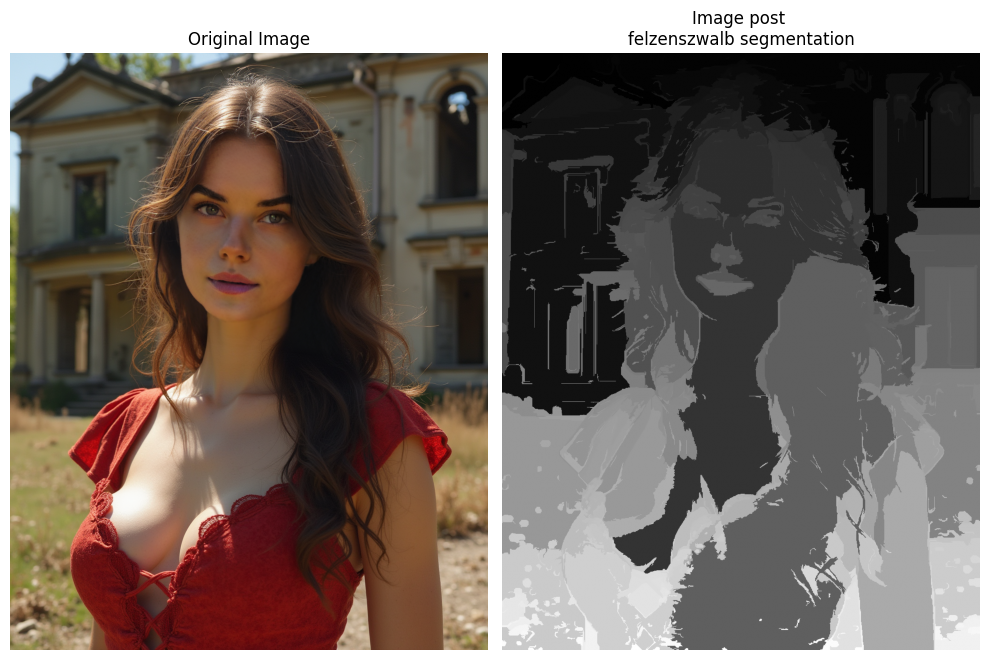

In [8]:
subplots([img, segments_fz], titles=['Original Image','Image post \nfelzenszwalb segmentation'], figsize=(10,10), nc=2)

### Pixels that have similar values form a region proposal.
### This helps in Object Detection, as we now pass each region proposal to a network and ask it to predict whether the region proposal is a background or an object.

 Furthermore, if it is an object , it helps us to identify the offset to fetch the tight bounding box corresponding to the object and the class corresponding to the content within the region proposal.

## Implementing Selective Search to generate region proposals

In [11]:
%pip install selectivesearch
%pip install torch_snippets
from torch_snippets import *
import selectivesearch

img = read('/content/emily.png', 1)

In [16]:
def extract_candidates(img):
    img_lbl, regions = selectivesearch.selective_search(img, scale=200, min_size=100)
    img_area = np.prod(img.shape[:2])
    candidates = []
    for r in regions:   # fetching only those candidates that are over 5 % of the total image area and less than or equal to 100% of the image area.
        if r['rect'] in candidates: continue
        if r['size'] < (0.05*img_area): continue
        if r['size'] > (1*img_area): continue
        x, y, w, h = r['rect']
        candidates.append(list(r['rect']))
    return candidates


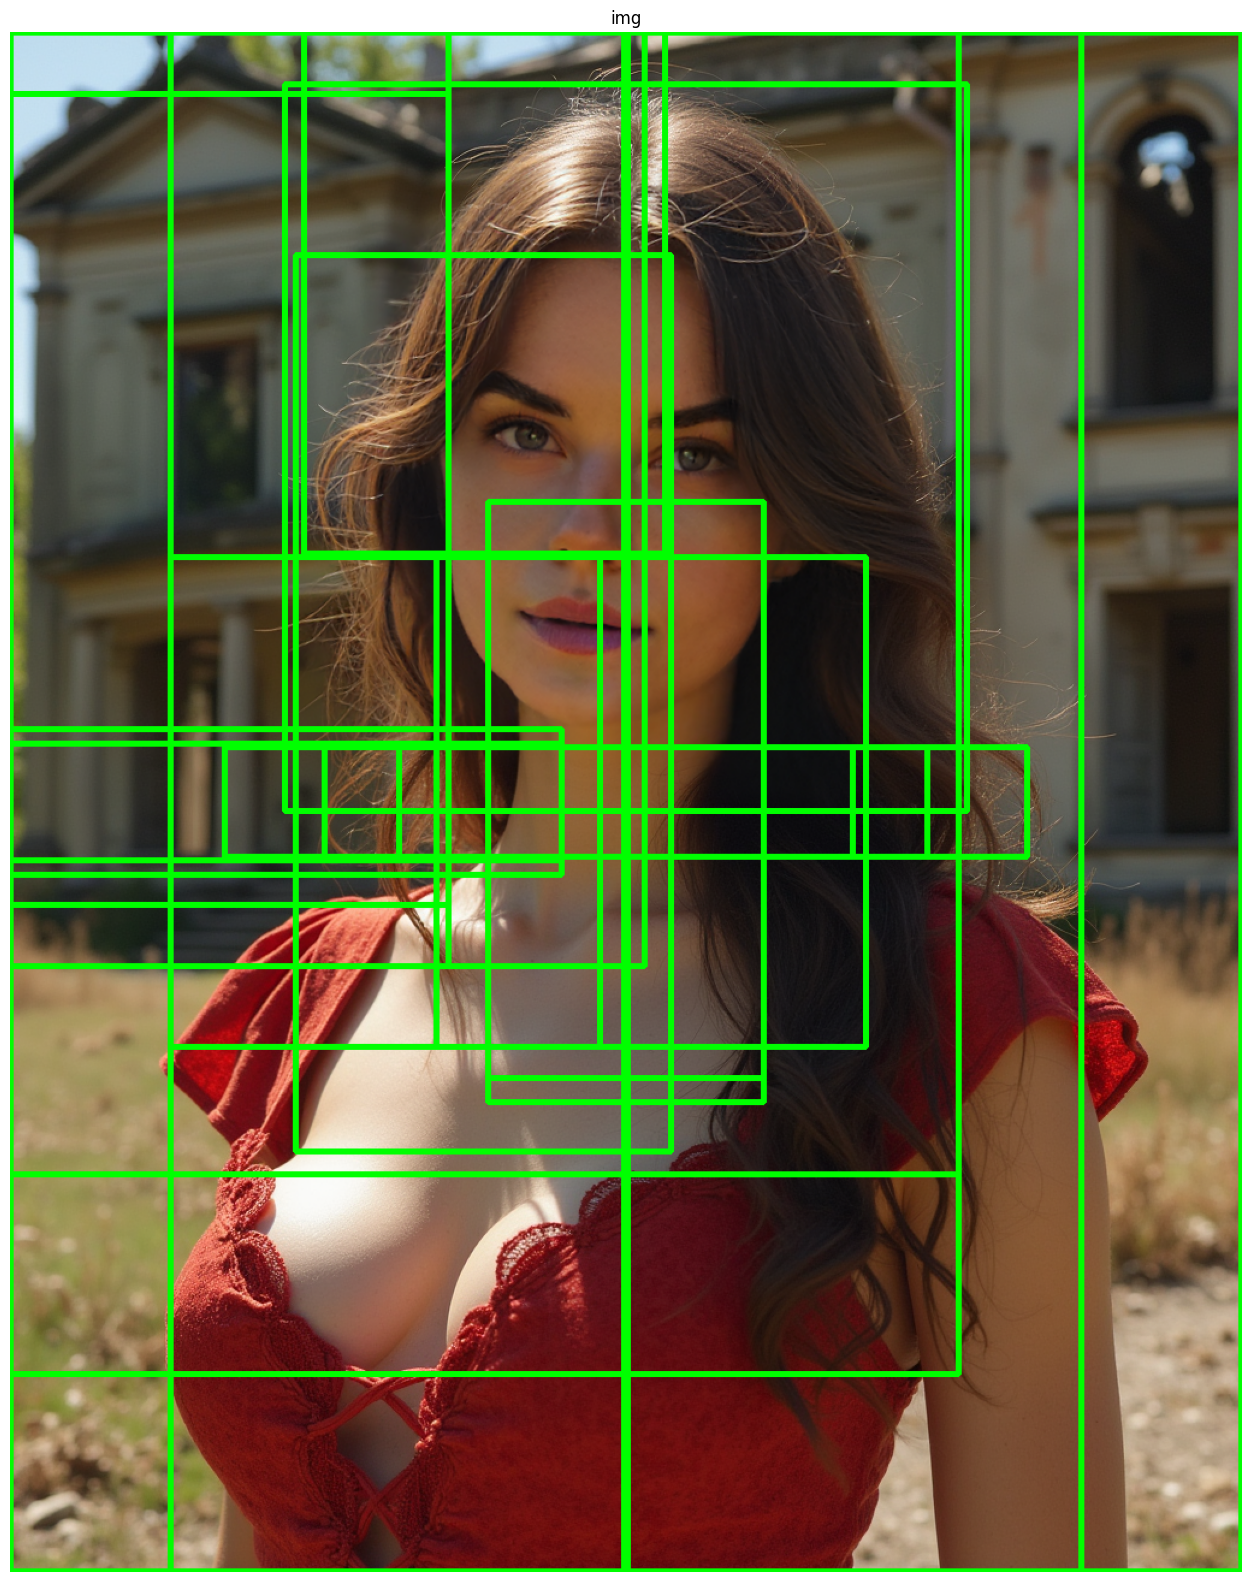

In [17]:
candidates = extract_candidates(img)
show(img, bbs = candidates)

## A `region proposal` that has `high intersection` with the location (ground truth) of an object in the image of interest is labeled as the one that contains the `object`, and the `region proposal` with a `low intersection` is labeled as the `background`